In [3]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from point_e.models.download import load_checkpoint
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.util.pc_to_mesh import marching_cubes_mesh
from point_e.util.plotting import plot_point_cloud
from point_e.util.point_cloud import PointCloud

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('creating SDF model...')
name = 'sdf'
model = model_from_config(MODEL_CONFIGS[name], device)
model.eval()

print('loading SDF model...')
model.load_state_dict(load_checkpoint(name, device))

creating SDF model...
loading SDF model...


  0%|          | 0.00/38.0M [00:00<?, ?iB/s]

c:\users\cwl\desktop\my_code_tree\point-e\point_e\models\download.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=device)


<All keys matched successfully>

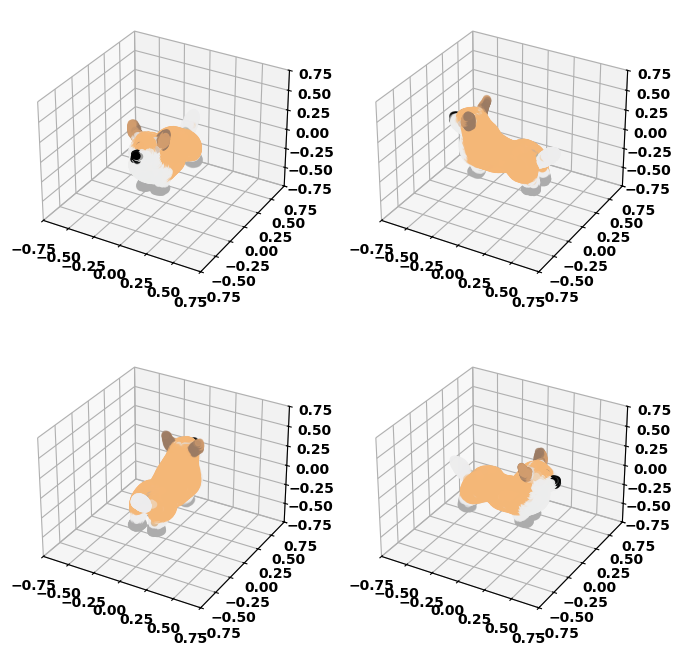

In [5]:
# Load a point cloud we want to convert into a mesh.
pc = PointCloud.load('example_data/pc_corgi.npz')

# Plot the point cloud as a sanity check.
fig = plot_point_cloud(pc, grid_size=2)

In [6]:
# Produce a mesh (with vertex colors)
mesh = marching_cubes_mesh(
    pc=pc,
    model=model,
    batch_size=4096,
    grid_size=32, # increase to 128 for resolution used in evals
    progress=True,
)

  0%|          | 0/8 [00:00<?, ?it/s]

In [7]:
# Write the mesh to a PLY file to import into some other program.
with open('mesh.ply', 'wb') as f:
    mesh.write_ply(f)

In [ ]:
#这段代码是可视化mesh的部分
import open3d as o3d
# 读取 PLY 文件
mesh = o3d.io.read_triangle_mesh("mesh.ply")
# 检查网格是否正确加载
if not mesh.has_vertices() or not mesh.has_triangles():
    print("错误：网格文件不包含顶点或三角面片")
else:
    # 可视化网格
    o3d.visualization.draw_geometries([mesh])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
#下面这一段是丰富的可视化mesh的代码
import open3d as o3d
import numpy as np

# 读取 PLY 文件
mesh = o3d.io.read_triangle_mesh("mesh.ply")

# 检查网格是否正确加载
if not mesh.has_vertices() or not mesh.has_triangles():
    print("错误：网格文件不包含顶点或三角面片")
else:
    # 创建一个可视化窗口
    vis = o3d.visualization.VisualizerWithKeyCallback()
    vis.create_window(window_name="Mesh Visualization", width=800, height=600)

    # 添加网格到可视化窗口
    vis.add_geometry(mesh)

    # 设置初始视图参数
    view_control = vis.get_view_control()
    view_control.set_front([0.5, -0.5, 0.5])  # 设置视角
    view_control.set_lookat(mesh.get_center())  # 设置观察点
    view_control.set_up([0, 0, 1])  # 设置向上方向
    view_control.set_zoom(0.7)  # 设置缩放比例

    # 添加光照效果
    render_option = vis.get_render_option()
    render_option.point_size = 1.0
    render_option.line_width = 1.0
    render_option.background_color = np.asarray([1.0, 1.0, 1.0])  # 白色背景
    render_option.light_on = True  # 启用光照

    # 定义按键回调函数
    def toggle_wireframe(vis):
        render_option = vis.get_render_option()
        render_option.mesh_show_wireframe = not render_option.mesh_show_wireframe
        return False

    def save_screenshot(vis):
        vis.capture_screen_image("screenshot.png", do_render=True)
        print("截图已保存为 screenshot.png")
        return False

    def toggle_light(vis):
        render_option = vis.get_render_option()
        render_option.light_on = not render_option.light_on
        return False

    def toggle_background(vis):
        render_option = vis.get_render_option()
        if np.allclose(render_option.background_color, [1.0, 1.0, 1.0]):
            render_option.background_color = np.asarray([0.0, 0.0, 0.0])
        else:
            render_option.background_color = np.asarray([1.0, 1.0, 1.0])
        return False

    # 注册按键回调
    vis.register_key_callback(ord("W"), toggle_wireframe)  # 按 'W' 切换线框模式
    vis.register_key_callback(ord("S"), save_screenshot)   # 按 'S' 保存截图
    vis.register_key_callback(ord("L"), toggle_light)      # 按 'L' 切换光照
    vis.register_key_callback(ord("B"), toggle_background) # 按 'B' 切换背景颜色

    # 启动可视化
    vis.run()
    vis.destroy_window()

截图已保存为 screenshot.png
截图已保存为 screenshot.png
